# Phần 1 — Khám phá dữ liệu (EDA): Bộ dữ liệu UCI Land Mines

**Mục tiêu.** Hiểu rõ cấu trúc, chất lượng và đặc điểm thống kê của bộ dữ liệu *trước khi* mô hình hóa, đồng thời đặt nền cho phần phản biện bài báo Yilmaz và cộng sự (2018).

**Bối cảnh dữ liệu (theo bài báo).** Bộ dữ liệu gốc có 352 mẫu; sau khi làm sạch 14 mẫu nhiễu còn **338 mẫu**, mỗi mẫu là véc-tơ 4 chiều `<V, H, S, M>`:
- `V` — điện áp cảm biến FLC (đại diện dị thường từ), gốc [0V; 10,6V].
- `H` — chiều cao đầu dò so với mặt đất, gốc [0cm; 20cm].
- `S` — loại đất (6 loại theo độ ẩm), là biến **hạng mục**.
- `M` — loại mìn (biến mục tiêu), 5 lớp: 1=Không mìn, 2=Chống tăng, 3=Chống bộ binh, 4=Bẫy chống bộ binh, 5=M14.

**Hai bài toán con** (rất quan trọng cho phần đánh giá sau này):
1. **Phát hiện (detection)** — nhị phân: có mìn (M∈{2,3,4,5}) vs không mìn (M=1).
2. **Phân loại (classification)** — 5 lớp.

> **Lưu ý về rò rỉ dữ liệu (leakage).** EDA ở đây thực hiện trên *toàn bộ* dữ liệu chỉ để mô tả/quan sát. Mọi quyết định định lượng dùng cho mô hình (tham số chuẩn hóa, chọn đặc trưng, ngưỡng) ở các phần sau **phải** được ước lượng **chỉ trên tập train**. Ngoài ra, dữ liệu UCI đã được chuẩn hóa [0,1] *trên toàn tập trước khi chia* — đây là một dạng rò rỉ nhẹ ở tiền xử lý mà ta sẽ ghi nhận như một giới hạn (xem ô thống kê mô tả).

## 1. Thiết lập môi trường

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Cấu hình hiển thị nhất quán cho toàn notebook
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.width", 120)

# Thư mục lưu hình; tự tạo nếu chưa có (tránh lỗi khi savefig)
FIG_DIR = "../Result/Figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Nhãn loại mìn để hiển thị dễ đọc
NHAN_MIN = {1: "Không mìn", 2: "Chống tăng", 3: "Chống bộ binh",
            4: "Bẫy chống bộ binh", 5: "M14"}

## 2. Nạp dữ liệu

File nguồn là `.xls` (định dạng Excel cũ) nên cần engine `xlrd`. Ta chỉ định tường minh engine để đảm bảo tái lập; có nhánh dự phòng nếu môi trường dùng engine khác.

In [2]:
DUONG_DAN = "../Data/Mine_Dataset_main.xls"

try:
    df = pd.read_excel(DUONG_DAN, engine="xlrd")
except Exception as e:
    print("xlrd lỗi, thử engine mặc định:", e)
    df = pd.read_excel(DUONG_DAN)

# Chuẩn hóa tên cột về đúng V, H, S, M (phòng khi header khác)
df.columns = [str(c).strip() for c in df.columns]
if list(df.columns[:4]) != ["V", "H", "S", "M"]:
    df = df.rename(columns=dict(zip(df.columns[:4], ["V", "H", "S", "M"])))
df["M"] = df["M"].astype(int)
df.head()

,V,H,S,M
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


## 3. Cấu trúc và kiểu dữ liệu

Kiểm tra kích thước, kiểu dữ liệu và vài dòng đầu. Kỳ vọng: **338 dòng × 4 cột**, `V/H/S` là số thực, `M` là số nguyên.

In [3]:
print("Kích thước:", df.shape)          # kỳ vọng (338, 4)
print()
df.info()

Kích thước: (338, 4)

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   V       338 non-null    float64
 1   H       338 non-null    float64
 2   S       338 non-null    float64
 3   M       338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


## 4. Thống kê mô tả — và bằng chứng dữ liệu đã chuẩn hóa sẵn

`describe()` cho thấy `V, H, S` đều nằm trong [0,1]. Đây là **bằng chứng** rằng dữ liệu đã được chuẩn hóa từ trước *trên toàn bộ tập*.

**Hệ quả về phương pháp:** vì min/max dùng để chuẩn hóa đã "nhìn thấy" cả các mẫu sẽ thuộc tập test, nên có một mức rò rỉ tiền xử lý không thể loại bỏ (do không có dữ liệu thô). Ta ghi nhận điều này như một **giới hạn** và, ở các phần mô hình, sẽ **không** thực hiện thêm bất kỳ phép scale nào dựa trên toàn tập.

In [4]:
desc = df.describe()
print(desc.round(4))
print()
print("min/max từng cột (xác nhận đã chuẩn hóa [0,1]):")
print(df[["V", "H", "S"]].agg(["min", "max"]).round(4))

              V         H         S         M
count  338.0000  338.0000  338.0000  338.0000
mean     0.4306    0.5089    0.5036    2.9527
std      0.1958    0.3060    0.3442    1.4197
min      0.1977    0.0000    0.0000    1.0000
25%      0.3097    0.2727    0.2000    2.0000
50%      0.3595    0.5455    0.6000    3.0000
75%      0.4826    0.7273    0.8000    4.0000
max      1.0000    1.0000    1.0000    5.0000

min/max từng cột (xác nhận đã chuẩn hóa [0,1]):
          V    H    S
min  0.1977  0.0  0.0
max  1.0000  1.0  1.0


## 5. `S` là biến hạng mục, không phải biến liên tục

`S` chỉ nhận 6 giá trị rời rạc {0.0, 0.2, 0.4, 0.6, 0.8, 1.0} tương ứng 6 loại đất. Bài báo mã hóa `S` thành số thứ tự và dùng trực tiếp trong khoảng cách k-NN — điều này **áp đặt một thứ tự và khoảng cách giả** giữa các loại đất (ví dụ "khô-cát" gần "khô-mùn" hơn "ẩm-sét" một cách nhân tạo).

Ta xác nhận tính rời rạc của `S` (và của `H`) tại đây; ở phần mô hình sẽ **thử one-hot cho `S`** và so sánh, để không lặp lại đúng lỗi mà ta phê phán.

In [5]:
for cot in ["H", "S", "M"]:
    gt = sorted(df[cot].unique().tolist())
    print(f"{cot}: {len(gt)} giá trị -> {np.round(gt, 4).tolist()}")

H: 12 giá trị -> [0.0, 0.0909, 0.1818, 0.2727, 0.3636, 0.4545, 0.5455, 0.6364, 0.7273, 0.8182, 0.9091, 1.0]
S: 6 giá trị -> [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
M: 5 giá trị -> [1, 2, 3, 4, 5]


## 6. Chất lượng dữ liệu: thiếu và trùng lặp

Kiểm tra giá trị khuyết và bản ghi trùng. Kỳ vọng: 0 khuyết, 0 trùng (dữ liệu đã được làm sạch).

In [6]:
print("Số giá trị khuyết theo cột:")
print(df.isnull().sum())
print()
print("Số dòng trùng lặp hoàn toàn:", int(df.duplicated().sum()))

Số giá trị khuyết theo cột:
V    0
H    0
S    0
M    0
dtype: int64

Số dòng trùng lặp hoàn toàn: 0


## 7. Hai bài toán con và vấn đề mất cân bằng lớp

Đây là phần **bổ sung then chốt** cho luận điểm phản biện. Bài báo báo cáo *accuracy* — chỉ số này gây hiểu nhầm khi lớp mất cân bằng.

- **Phân loại (5 lớp):** khá cân bằng (~20% mỗi lớp) → baseline ngẫu nhiên ≈ 20%.
- **Phát hiện (nhị phân):** ~**79% có mìn / 21% không mìn** → mô hình đoán "luôn có mìn" đã đạt ~79% accuracy mà vô dụng. Vì vậy ở phần đánh giá phải dùng **recall của lớp "có mìn" (không bỏ sót mìn)**, precision và F1, chứ không chỉ accuracy.

In [7]:
# Tạo nhãn phát hiện nhị phân: 1 = có mìn, 0 = không mìn
df["detect"] = (df["M"] != 1).astype(int)

print("Phân bố 5 lớp (bài toán phân loại):")
pb5 = df["M"].value_counts().sort_index()
for m, n in pb5.items():
    print(f"  {m} ({NHAN_MIN[m]:<18}): {n:3d}  ({n/len(df)*100:4.1f}%)")

print("\nPhân bố nhị phân (bài toán phát hiện):")
pb2 = df["detect"].value_counts().sort_index()
print(f"  0 (Không mìn): {pb2.get(0,0):3d}  ({pb2.get(0,0)/len(df)*100:4.1f}%)")
print(f"  1 (Có mìn)   : {pb2.get(1,0):3d}  ({pb2.get(1,0)/len(df)*100:4.1f}%)")

Phân bố 5 lớp (bài toán phân loại):
  1 (Không mìn         ):  71  (21.0%)
  2 (Chống tăng        ):  70  (20.7%)
  3 (Chống bộ binh     ):  66  (19.5%)
  4 (Bẫy chống bộ binh ):  66  (19.5%)
  5 (M14               ):  65  (19.2%)

Phân bố nhị phân (bài toán phát hiện):
  0 (Không mìn):  71  (21.0%)
  1 (Có mìn)   : 267  (79.0%)


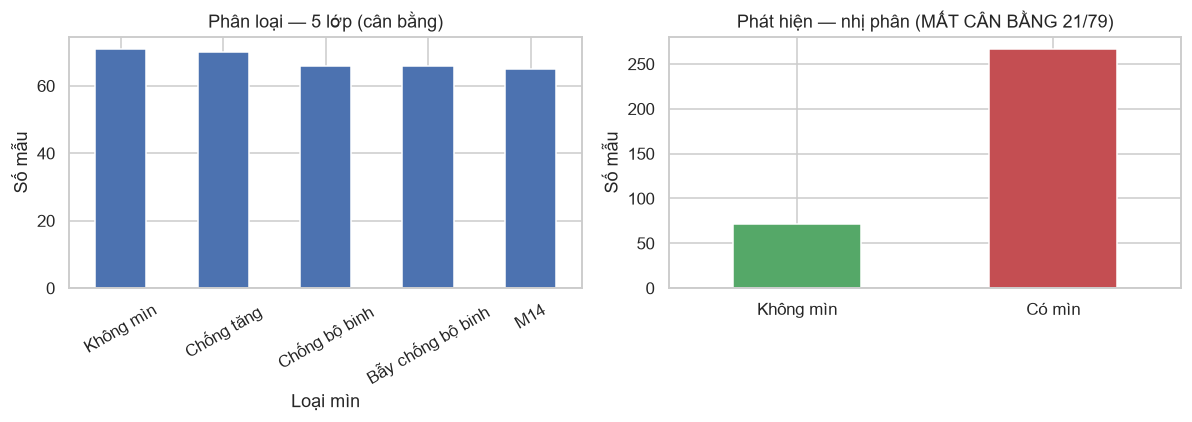

In [8]:
# Trực quan hóa phân bố của hai bài toán
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

pb5.rename(index=NHAN_MIN).plot(kind="bar", ax=ax[0], color=sns.color_palette("deep")[0])
ax[0].set_title("Phân loại — 5 lớp (cân bằng)")
ax[0].set_xlabel("Loại mìn"); ax[0].set_ylabel("Số mẫu")
ax[0].tick_params(axis="x", rotation=30)

pb2.rename(index={0: "Không mìn", 1: "Có mìn"}).plot(
    kind="bar", ax=ax[1], color=[sns.color_palette("deep")[2], sns.color_palette("deep")[3]])
ax[1].set_title("Phát hiện — nhị phân (MẤT CÂN BẰNG 21/79)")
ax[1].set_xlabel(""); ax[1].set_ylabel("Số mẫu")
ax[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_phan_bo_hai_bai_toan.png", bbox_inches="tight")
plt.show()

## 8. Quan hệ giữa dị thường từ `V` và loại mìn `M`

Boxplot `V` theo từng loại mìn cho thấy `V` có sức phân biệt mạnh (đặc biệt lớp Chống tăng có `V` cao rõ rệt). Đây là bằng chứng định tính đầu tiên cho thứ tự tầm quan trọng đặc trưng **V > H > S** mà ta sẽ kiểm định định lượng ở phần sau.

C:\Users\quang\AppData\Local\Temp\ipykernel_23064\3378633696.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels([NHAN_MIN[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30)


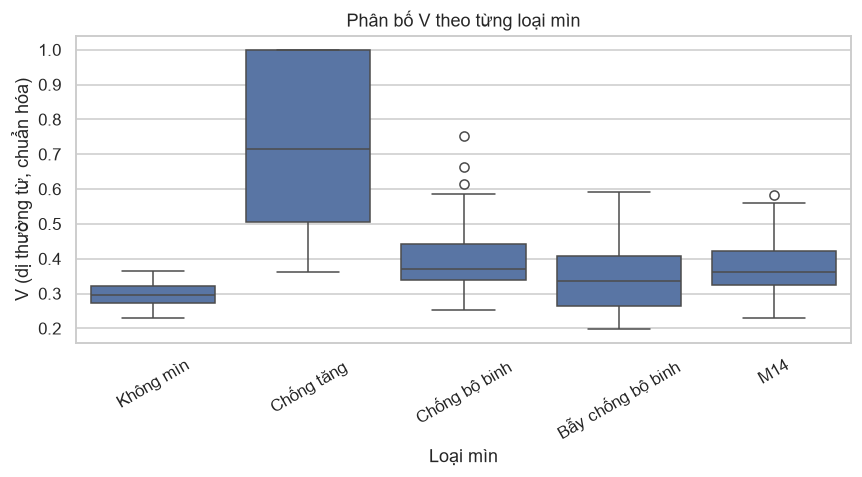

In [9]:
plt.figure(figsize=(8, 4.5))
ax = sns.boxplot(data=df, x="M", y="V")
ax.set_xticklabels([NHAN_MIN[int(t.get_text())] for t in ax.get_xticklabels()], rotation=30)
ax.set_xlabel("Loại mìn"); ax.set_ylabel("V (dị thường từ, chuẩn hóa)")
ax.set_title("Phân bố V theo từng loại mìn")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_V_theo_loai_min.png", bbox_inches="tight")
plt.show()

## 9. Ảnh hưởng của chiều cao `H`

Scatter `H`–`V` tô màu theo loại mìn: kiểm tra xem tín hiệu `V` thay đổi thế nào theo chiều cao đo. Bài báo lập luận rằng dị thường từ suy giảm khi đầu dò rời xa mặt đất — kỳ vọng thấy `V` có xu hướng giảm khi `H` tăng ở các lớp mìn mạnh.

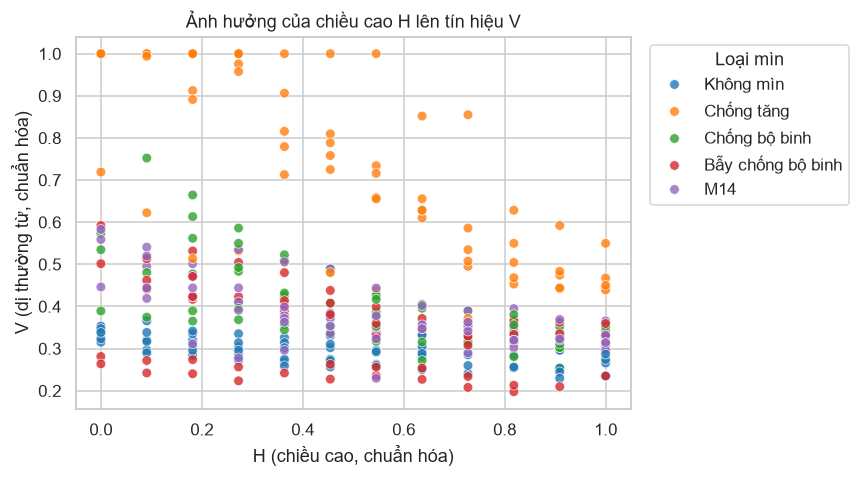

In [10]:
plt.figure(figsize=(8, 4.5))
ax = sns.scatterplot(data=df, x="H", y="V", hue="M", palette="tab10", s=40, alpha=0.8)
ax.set_xlabel("H (chiều cao, chuẩn hóa)"); ax.set_ylabel("V (dị thường từ, chuẩn hóa)")
ax.set_title("Ảnh hưởng của chiều cao H lên tín hiệu V")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [NHAN_MIN[int(l)] for l in labels], title="Loại mìn",
          bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_anh_huong_do_cao.png", bbox_inches="tight")
plt.show()

## 10. Ảnh hưởng của loại đất `S`

Boxplot `V` theo `S`, tách theo loại mìn. Lưu ý: `S` ở đây được vẽ như trục hạng mục (6 loại đất) — **không** ngụ ý thứ tự thực. Mục tiêu là xem loại đất có làm dịch chuyển phân bố `V` hay không, cho từng loại mìn.

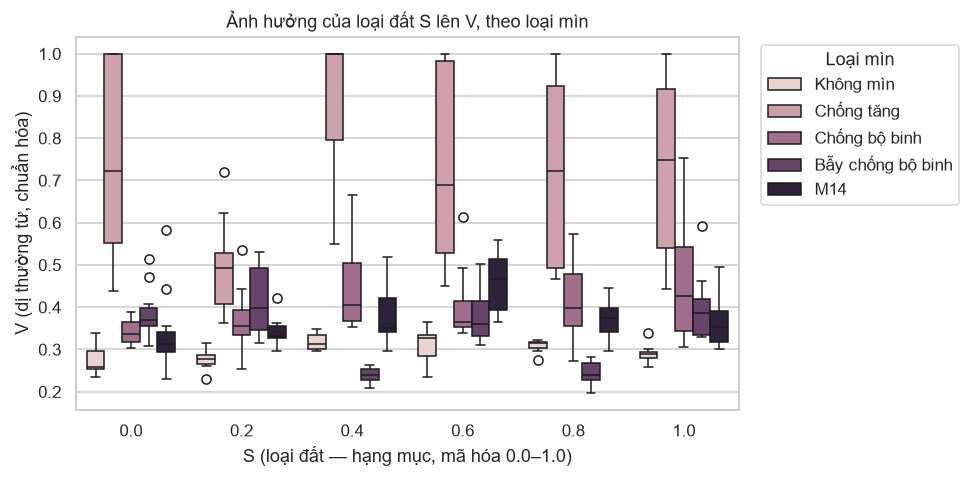

In [11]:
plt.figure(figsize=(9, 4.5))
ax = sns.boxplot(data=df, x="S", y="V", hue="M")
ax.set_xlabel("S (loại đất — hạng mục, mã hóa 0.0–1.0)")
ax.set_ylabel("V (dị thường từ, chuẩn hóa)")
ax.set_title("Ảnh hưởng của loại đất S lên V, theo loại mìn")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [NHAN_MIN[int(l)] for l in labels], title="Loại mìn",
          bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_anh_huong_loai_dat.png", bbox_inches="tight")
plt.show()

## 11. Tương quan sơ bộ giữa đặc trưng và mục tiêu phát hiện

Dùng **tương quan Spearman** (hạng) vì `S`, `H` rời rạc và quan hệ có thể phi tuyến; đây chỉ là chỉ báo định hướng, không thay cho kiểm định tầm quan trọng đặc trưng ở phần mô hình (permutation importance). Ta xét tương quan với nhãn `detect` (có/không mìn) để có ý nghĩa hơn so với nhãn `M` đa lớp.

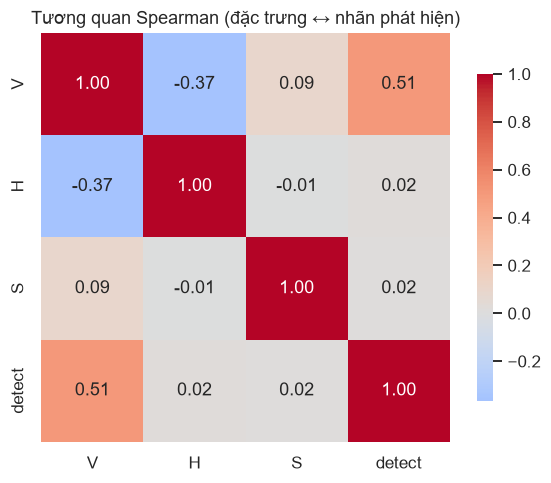

Tương quan |Spearman| với nhãn phát hiện (giảm dần):
V    0.508
H    0.022
S    0.016
Name: detect, dtype: float64


In [12]:
corr = df[["V", "H", "S", "detect"]].corr(method="spearman")
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
            square=True, cbar_kws={"shrink": 0.8})
plt.title("Tương quan Spearman (đặc trưng ↔ nhãn phát hiện)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_tuong_quan_spearman.png", bbox_inches="tight")
plt.show()

print("Tương quan |Spearman| với nhãn phát hiện (giảm dần):")
print(corr["detect"].drop("detect").abs().sort_values(ascending=False).round(3))

## 12. Kết luận Phần 1 và những điều mang sang các phần sau

**Đã xác nhận (khớp bài báo):** 338 mẫu × 4 cột; không khuyết, không trùng; `V,H,S` đã chuẩn hóa [0,1]; phân loại 5 lớp cân bằng (71/70/66/66/65); `V` phân biệt mạnh theo loại mìn.

**Phát hiện bổ sung / giới hạn cần ghi vào đồ án:**
1. **Rò rỉ tiền-chuẩn-hóa:** dữ liệu đã scale trên toàn tập trước khi chia — không thể sửa (thiếu dữ liệu thô), phải nêu như giới hạn và không scale lại theo toàn tập ở phần sau.
2. **Mất cân bằng ở bài toán phát hiện (21/79):** bắt buộc dùng recall/precision/F1 cho lớp "có mìn", không chỉ accuracy.
3. **`S` là hạng mục:** cần thử one-hot ở phần mô hình để tránh áp đặt thứ tự giả trong khoảng cách k-NN.

**Ràng buộc trực tiếp cho các phần mô hình (chính là chỗ khắc phục lỗi bài báo):**
- Tách **validation riêng** làm hàm mục tiêu cho tối ưu trọng số (DE/GA), **tuyệt đối không** dùng tập test làm fitness (đây là lỗi rò rỉ cốt lõi ở Công thức 3 + Thuật toán 1 của bài báo).
- Đánh giá cuối trên **tập test độc lập** và/hoặc **nested cross-validation** để có ước lượng không chệch kèm độ lệch chuẩn.
- Kiểm định tầm quan trọng đặc trưng bằng **permutation importance** để đối chiếu với thứ tự V > H > S.